In [93]:
import mlx.core as mx
import mlx.nn as nn

def interpolate(x, size=None, scale_factor=None, mode="bilinear", align_corners=False):
    """
    Manual interpolation for MLX tensors (NHWC).
    Supports 'bilinear' and 'nearest'.
    """
    B, H, W, C = x.shape
    if size is not None:
        H_out, W_out = size
    elif scale_factor is not None:
        H_out, W_out = int(H * scale_factor), int(W * scale_factor)
    else:
        raise ValueError("Either size or scale_factor must be defined")

    if mode == "nearest":
        y_indices = (mx.arange(H_out) * (H / H_out)).astype(mx.int32)
        x_indices = (mx.arange(W_out) * (W / W_out)).astype(mx.int32)
        return x[:, y_indices][:, :, x_indices]
    
    if mode == "bilinear":
        sy = (H - 1) / (H_out - 1) if align_corners and H_out > 1 else H / H_out
        sx = (W - 1) / (W_out - 1) if align_corners and W_out > 1 else W / W_out

        y = mx.arange(H_out) * sy
        x_idx = mx.arange(W_out) * sx
        
        y_low = mx.floor(y).astype(mx.int32)
        y_high = mx.minimum(y_low + 1, H - 1)
        y_lerp = (y - y_low).reshape(1, H_out, 1, 1)

        x_low = mx.floor(x_idx).astype(mx.int32)
        x_high = mx.minimum(x_low + 1, W - 1)
        x_lerp = (x_idx - x_low).reshape(1, 1, W_out, 1)

        c00 = x[:, y_low][:, :, x_low]
        c01 = x[:, y_low][:, :, x_high]
        c10 = x[:, y_high][:, :, x_low]
        c11 = x[:, y_high][:, :, x_high]

        return (c00 * (1 - x_lerp) + c01 * x_lerp) * (1 - y_lerp) + \
               (c10 * (1 - x_lerp) + c11 * x_lerp) * y_lerp

class Compose:
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, x):
        for t in self.transforms:
            x = t(x)
        return x
class ResidualConvUnit(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.conv1 = nn.Conv2d(features, features, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(features, features, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()

    def __call__(self, x):
        out = self.relu(x)
        out = self.conv1(out)
        out = self.relu(out)
        out = self.conv2(out)
        return x + out

class FeatureFusionBlock(nn.Module):
    def __init__(self, features, size=None):
        super().__init__()
        self.resConfUnit1 = ResidualConvUnit(features)
        self.resConfUnit2 = ResidualConvUnit(features)
        self.out_conv = nn.Conv2d(features, features, kernel_size=1, stride=1)
        self.size = size

    def __call__(self, *xs, size=None):
        size = size or self.size
        out = xs[0]
        if len(xs) == 2:
            out = out + self.resConfUnit1(xs[1])
        out = self.resConfUnit2(out)
        if size is not None:
            out = interpolate(out, size=size)
        return self.out_conv(out)

class Scratch(nn.Module):
    """Explicitly defined to match the PyTorch 'scratch' attribute."""
    def __init__(self, out_channels, features):
        super().__init__()
        self.layer1_rn = nn.Conv2d(out_channels[0], features, kernel_size=3, stride=1, padding=1, bias=False)
        self.layer2_rn = nn.Conv2d(out_channels[1], features, kernel_size=3, stride=1, padding=1, bias=False)
        self.layer3_rn = nn.Conv2d(out_channels[2], features, kernel_size=3, stride=1, padding=1, bias=False)
        self.layer4_rn = nn.Conv2d(out_channels[3], features, kernel_size=3, stride=1, padding=1, bias=False)
        
        self.refinenet1 = FeatureFusionBlock(features)
        self.refinenet2 = FeatureFusionBlock(features)
        self.refinenet3 = FeatureFusionBlock(features)
        self.refinenet4 = FeatureFusionBlock(features)
        
        self.output_conv1 = nn.Conv2d(features, features // 2, kernel_size=3, stride=1, padding=1)
        self.output_conv2 = nn.Sequential(
            nn.Conv2d(features // 2, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1, stride=1, padding=0),
            nn.ReLU()
        )

In [ ]:
import mlx.core as mx
import mlx.nn as nn

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.0, bias=True):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features, bias=bias)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features, bias=bias)
        self.drop = nn.Dropout(drop)

    def __call__(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

In [64]:
import mlx.core as mx
import mlx.nn as nn
from typing import Optional, Callable, Tuple, Union

def make_2tuple(x):
    """Converts input to a 2-element tuple if it's an integer."""
    if isinstance(x, tuple):
        assert len(x) == 2
        return x
    assert isinstance(x, int)
    return (x, x)

class PatchEmbed(nn.Module):
    """
    2D image to patch embedding: (B, H, W, C) -> (B, N, D)
    MLX implementation using NHWC (Batch, Height, Width, Channels) format.

    Args:
        img_size: Image size.
        patch_size: Patch token size.
        in_chans: Number of input image channels.
        embed_dim: Number of linear projection output channels.
        norm_layer: Normalization layer.
    """

    def __init__(
        self,
        img_size: Union[int, Tuple[int, int]] = 224,
        patch_size: Union[int, Tuple[int, int]] = 16,
        in_chans: int = 3,
        embed_dim: int = 768,
        norm_layer: Optional[Callable] = None,
        flatten_embedding: bool = True,
    ) -> None:
        super().__init__()

        image_HW = make_2tuple(img_size)
        patch_HW = make_2tuple(patch_size)
        patch_grid_size = (
            image_HW[0] // patch_HW[0],
            image_HW[1] // patch_HW[1],
        )

        self.img_size = image_HW
        self.patch_size = patch_HW
        self.patches_resolution = patch_grid_size
        self.num_patches = patch_grid_size[0] * patch_grid_size[1]

        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.flatten_embedding = flatten_embedding

        # MLX Conv2d expects NHWC input.
        # Weights layout: (Out, kH, kW, In). 
        # Note: PyTorch weights (Out, In, kH, kW) must be transposed to (0, 2, 3, 1) during loading.
        self.proj = nn.Conv2d(
            in_chans, 
            embed_dim, 
            kernel_size=patch_HW, 
            stride=patch_HW
        )
        
        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def __call__(self, x: mx.array) -> mx.array:
        """
        Forward pass for Patch Embedding.
        x: Input tensor of shape (B, H, W, C).
        """
        B, H, W, C = x.shape
        patch_H, patch_W = self.patch_size

        assert H % patch_H == 0, f"Input image height {H} is not a multiple of patch height {patch_H}"
        assert W % patch_W == 0, f"Input image width {W} is not a multiple of patch width: {patch_W}"

        # MLX Conv2d output is (B, H_out, W_out, D)
        x = self.proj(x)
        H_out, W_out = x.shape[1], x.shape[2]
        
        # Flatten spatial dimensions to match sequence format: (B, HW, D)
        # This matches the PyTorch x.flatten(2).transpose(1, 2) logic.
        x = x.reshape(B, -1, self.embed_dim)
        
        x = self.norm(x)
        
        if not self.flatten_embedding:
            # Restore spatial dims: (B, H_out, W_out, D)
            x = x.reshape(B, H_out, W_out, self.embed_dim)
            
        return x

    def flops(self) -> float:
        """Calculates floating point operations."""
        Ho, Wo = self.patches_resolution
        flops = Ho * Wo * self.embed_dim * self.in_chans * (self.patch_size[0] * self.patch_size[1])
        if not isinstance(self.norm, nn.Identity):
            flops += Ho * Wo * self.embed_dim
        return flops

In [65]:
class LayerScale(nn.Module):
    def __init__(self, dim, init_values=1e-5):
        super().__init__()
        self.gamma = mx.full((dim,), init_values)
    def __call__(self, x):
        return x * self.gamma

class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def __call__(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = mx.random.bernoulli(keep_prob, shape)
        return (x / keep_prob) * mask

In [66]:
class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, proj_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim**-0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim, bias=proj_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

    def __call__(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, -1).transpose(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(0, 1, 3, 2)) * self.scale
        attn = mx.softmax(attn, axis=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(0, 2, 1, 3).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

In [84]:
# depth_anything_v2/dinov2_layers/block.py (MLX Port)
import mlx.core as mx
import mlx.nn as nn
from typing import Callable, List, Any, Tuple, Optional


# Stochastic depth utility for dropping samples during computation
def drop_add_residual_stochastic_depth(
    x: mx.array,
    residual_func: Callable[[mx.array], mx.array],
    sample_drop_ratio: float = 0.0,
) -> mx.array:
    """
    MLX implementation of sample-dropping stochastic depth.
    Only computes the residual for a subset of the batch.
    """
    b, n, d = x.shape
    sample_subset_size = max(int(b * (1 - sample_drop_ratio)), 1)
    
    # Generate random indices for the subset
    # Using numpy for permutation as MLX doesn't have a native randperm yet
    import numpy as np
    indices = mx.array(np.random.permutation(b)[:sample_subset_size])
    
    x_subset = x[indices]
    
    # 2) apply residual_func to get residual
    residual = residual_func(x_subset)
    
    residual_scale_factor = b / sample_subset_size

    # 3) add the residual back to the original tensor
    # In MLX, we use scatter-add logic via indexing
    full_residual = mx.zeros_like(x)
    full_residual[indices] = residual * residual_scale_factor
    
    return x + full_residual

def get_branges_scales(x, sample_drop_ratio=0.0):
    b, n, d = x.shape
    sample_subset_size = max(int(b * (1 - sample_drop_ratio)), 1)
    import numpy as np
    brange = mx.array(np.random.permutation(b)[:sample_subset_size])
    residual_scale_factor = b / sample_subset_size
    return brange, residual_scale_factor

class Block(nn.Module):
    def __init__(
        self,
        dim: int,
        num_heads: int,
        mlp_ratio: float = 4.0,
        qkv_bias: bool = False,
        proj_bias: bool = True,
        ffn_bias: bool = True,
        drop: float = 0.0,
        attn_drop: float = 0.0,
        init_values=1.0,
        drop_path: float = 0.0,
        act_layer: Callable[..., nn.Module] = nn.GELU,
        norm_layer: Callable[..., nn.Module] = nn.LayerNorm,
        attn_class: Callable[..., nn.Module] = Attention,
        ffn_layer: Callable[..., nn.Module] = Mlp,
    ) -> None:
        super().__init__()
        
        self.norm1 = norm_layer(dim)
        self.attn = attn_class(
            dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            proj_bias=proj_bias,
            attn_drop=attn_drop,
            proj_drop=drop,
        )
        self.ls1 = LayerScale(dim, init_values=init_values) if init_values else nn.Identity()
        self.drop_path1 = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = ffn_layer(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=act_layer,
            drop=drop,
            bias=ffn_bias,
        )
        self.ls2 = LayerScale(dim, init_values=init_values) if init_values else nn.Identity()
        self.drop_path2 = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

        self.sample_drop_ratio = drop_path

    def __call__(self, x: mx.array) -> mx.array:
        def attn_residual_func(x: mx.array) -> mx.array:
            return self.ls1(self.attn(self.norm1(x)))

        def ffn_residual_func(x: mx.array) -> mx.array:
            return self.ls2(self.mlp(self.norm2(x)))

        # Training-time stochastic depth logic matching original code
        if self.training and self.sample_drop_ratio > 0.1:
            x = drop_add_residual_stochastic_depth(
                x,
                residual_func=attn_residual_func,
                sample_drop_ratio=self.sample_drop_ratio,
            )
            x = drop_add_residual_stochastic_depth(
                x,
                residual_func=ffn_residual_func,
                sample_drop_ratio=self.sample_drop_ratio,
            )
        elif self.training and self.sample_drop_ratio > 0.0:
            x = x + self.drop_path1(attn_residual_func(x))
            x = x + self.drop_path1(ffn_residual_func(x))
        else:
            x = x + attn_residual_func(x)
            x = x + ffn_residual_func(x)
        return x

class NestedTensorBlock(Block):
    """
    MLX version of NestedTensorBlock. 
    Handles lists of tensors for variable sequence length processing.
    """
    
    def forward_nested(self, x_list: List[mx.array]) -> List[mx.array]:
        # Implementation for processing lists of tensors.
        # While PyTorch uses xformers FMHA, MLX can handle varying sequences 
        # by iterating or using masks. To maintain the 'no simplification' rule,
        # we follow the logic of processing the entire list.
        
        if self.training and self.sample_drop_ratio > 0.0:
            # Stochastic depth for lists
            branges_scales = [get_branges_scales(x, self.sample_drop_ratio) for x in x_list]
            
            outputs = []
            for i, x in enumerate(x_list):
                brange, scale = branges_scales[i]
                
                # Attn
                x_subset = x[brange]
                res_attn = self.ls1(self.attn(self.norm1(x_subset)))
                full_res_attn = mx.zeros_like(x)
                full_res_attn[brange] = res_attn * scale
                x = x + full_res_attn
                
                # MLP
                x_subset = x[brange]
                res_mlp = self.ls2(self.mlp(self.norm2(x_subset)))
                full_res_mlp = mx.zeros_like(x)
                full_res_mlp[brange] = res_mlp * scale
                x = x + full_res_mlp
                
                outputs.append(x)
            return outputs
        else:
            # Standard inference/forward for list
            outputs = []
            for x in x_list:
                x = x + self.ls1(self.attn(self.norm1(x)))
                x = x + self.ls2(self.mlp(self.norm2(x)))
                outputs.append(x)
            return outputs

    def __call__(self, x_or_x_list):
        if isinstance(x_or_x_list, mx.array):
            return super().__call__(x_or_x_list)
        elif isinstance(x_or_x_list, list):
            return self.forward_nested(x_or_x_list)
        else:
            raise AssertionError(f"Unsupported input type: {type(x_or_x_list)}")

In [89]:
class BlockChunk(nn.Module):
    def __init__(self, blocks):
        super().__init__()
        self.block_list = blocks
    def __call__(self, x):
        for b in self.block_list:
            x = b(x)
        return x

class DinoVisionTransformer(nn.Module):
    def __init__(
        self,
        img_size=518,
        patch_size=14,
        in_chans=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        qkv_bias=True,
        ffn_bias=True,
        proj_bias=True,
        drop_path_rate=0.0,
        drop_path_uniform=False,
        init_values=1.0,
        embed_layer=PatchEmbed,
        act_layer=nn.GELU,
        block_fn=Block,
        ffn_layer="mlp",
        block_chunks=0,
        num_register_tokens=0,
        interpolate_antialias=False,
        interpolate_offset=0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.num_tokens = 1
        self.num_register_tokens = num_register_tokens
        self.interpolate_antialias = interpolate_antialias
        self.interpolate_offset = interpolate_offset

        self.patch_embed = embed_layer(img_size=img_size, patch_size=patch_size, in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        # Parameters (Must be mx.array to be recognized by update())
        self.cls_token = mx.zeros((1, 1, embed_dim))
        self.pos_embed = mx.zeros((1, num_patches + self.num_tokens, embed_dim))
        self.mask_token = mx.zeros((1, embed_dim))
        
        if num_register_tokens > 0:
            self.register_tokens = mx.zeros((1, num_register_tokens, embed_dim))
        else:
            self.register_tokens = None

        # Stochastic depth decay rule
        if drop_path_uniform:
            dpr = [drop_path_rate] * depth
        else:
            dpr = [x.item() for x in mx.linspace(0, drop_path_rate, depth)]

        # Blocks
        blocks_list = [
            block_fn(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                proj_bias=proj_bias,
                ffn_bias=ffn_bias,
                drop_path=dpr[i],
                init_values=init_values,
            )
            for i in range(depth)
        ]

        if block_chunks > 0:
            self.chunked_blocks = True
            chunksize = depth // block_chunks
            self.blocks = [
                BlockChunk(blocks_list[i : i + chunksize]) 
                for i in range(0, depth, chunksize)
            ]
        else:
            self.chunked_blocks = False
            self.blocks = blocks_list

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Identity()

    def interpolate_pos_encoding(self, x, w, h):
        B, N_tokens, C = x.shape
        npatch = N_tokens - 1
        N = self.pos_embed.shape[1] - 1
        
        if npatch == N and w == h:
            return self.pos_embed

        class_pos_embed = self.pos_embed[:, :1]
        patch_pos_embed = self.pos_embed[:, 1:]
        
        dim = C
        w0 = w // self.patch_size
        h0 = h // self.patch_size
        
        w0, h0 = w0 + self.interpolate_offset, h0 + self.interpolate_offset
        
        sqrt_N = int(math.sqrt(N))
        # Reshape to NHWC for MLX interpolate
        patch_pos_embed = patch_pos_embed.reshape(1, sqrt_N, sqrt_N, dim)
        patch_pos_embed = interpolate_bilinear(patch_pos_embed, (int(h0), int(w0)))
        patch_pos_embed = patch_pos_embed.reshape(1, -1, dim)
        
        return mx.concatenate([class_pos_embed, patch_pos_embed], axis=1)

    def prepare_tokens_with_masks(self, x, masks=None):
        B, H, W, C = x.shape
        x = self.patch_embed(x) # (B, N, D)
        
        if masks is not None:
            # masks shape usually (B, N)
            m = mx.expand_dims(masks, -1)
            x = mx.where(m, self.mask_token, x)

        cls_token = mx.broadcast_to(self.cls_token, (x.shape[0], 1, x.shape[-1]))
        x = mx.concatenate([cls_token, x], axis=1)
        x = x + self.interpolate_pos_encoding(x, W, H)

        if self.register_tokens is not None:
            reg_tokens = mx.broadcast_to(self.register_tokens, (x.shape[0], self.num_register_tokens, x.shape[-1]))
            x = mx.concatenate([x[:, :1], reg_tokens, x[:, 1:]], axis=1)
            
        return x

    def forward_features(self, x, masks=None):
        x = self.prepare_tokens_with_masks(x, masks)

        for blk in self.blocks:
            x = blk(x)

        x_norm = self.norm(x)
        
        # Slicing matching PyTorch precisely
        return {
            "x_norm_clstoken": x_norm[:, 0],
            "x_norm_regtokens": x_norm[:, 1 : self.num_register_tokens + 1],
            "x_norm_patchtokens": x_norm[:, self.num_register_tokens + 1 :],
            "x_prenorm": x,
            "masks": masks,
        }

    def get_intermediate_layers(self, x, n=1, reshape=False, return_class_token=False, norm=True):
        B, H, W, _ = x.shape
        x = self.prepare_tokens_with_masks(x)
        
        output = []
        # Total blocks logic for chunked vs non-chunked
        if self.chunked_blocks:
            all_blocks = [b for chunk in self.blocks for b in chunk.block_list]
        else:
            all_blocks = self.blocks
            
        total_len = len(all_blocks)
        blocks_to_take = range(total_len - n, total_len) if isinstance(n, int) else n
        
        for i, blk in enumerate(all_blocks):
            x = blk(x)
            if i in blocks_to_take:
                output.append(x)
        
        if norm:
            output = [self.norm(out) for out in output]
            
        class_tokens = [out[:, 0] for out in output]
        # Skip cls + registers
        output = [out[:, 1 + self.num_register_tokens:] for out in output]
        
        if reshape:
            output = [
                out.reshape(B, H // self.patch_size, W // self.patch_size, -1)
                for out in output
            ]
            
        if return_class_token:
            return tuple(zip(output, class_tokens))
        return tuple(output)

    def __call__(self, x, is_training=False):
        ret = self.forward_features(x)
        if is_training:
            return ret
        return self.head(ret["x_norm_clstoken"])

In [103]:
import cv2
import numpy as np
import mlx.core as mx
import mlx.nn as nn

class DPTHead(nn.Module):
    def __init__(self, in_channels, features=256, out_channels=[256, 512, 1024, 1024], use_clstoken=False):
        super().__init__()
        self.use_clstoken = use_clstoken
        
        # Note: MLX nn.ModuleList tracks modules in a standard list
        self.projects = [
            nn.Conv2d(in_channels, out, kernel_size=1) for out in out_channels
        ]
        
        # Upsampling via ConvTranspose2d (NHWC layout)
        self.resize_layers = [
            nn.ConvTranspose2d(out_channels[0], out_channels[0], kernel_size=4, stride=4),
            nn.ConvTranspose2d(out_channels[1], out_channels[1], kernel_size=2, stride=2),
            nn.Identity(),
            nn.Conv2d(out_channels[3], out_channels[3], kernel_size=3, stride=2, padding=1)
        ]
        
        if use_clstoken:
            self.readout_projects = [
                nn.Sequential(nn.Linear(2 * in_channels, in_channels), nn.GELU())
                for _ in range(len(out_channels))
            ]
            
        # The 'scratch' submodule that fixed your previous error
        self.scratch = Scratch(out_channels, features)

    def __call__(self, out_features, patch_h, patch_w):
        out = []
        for i, x_data in enumerate(out_features):
            if self.use_clstoken:
                x, cls_token = x_data[0], x_data[1]
                # x: (B, HW, C), cls_token: (B, C)
                readout = mx.broadcast_to(mx.expand_dims(cls_token, 1), x.shape)
                x = self.readout_projects[i](mx.concatenate([x, readout], axis=-1))
            else:
                x = x_data[0]
            
            # Reshape tokens to spatial grid (B, H, W, C) for MLX Conv2d
            x = x.reshape(x.shape[0], patch_h, patch_w, -1)
            
            x = self.projects[i](x)
            x = self.resize_layers[i](x)
            out.append(x)
        
        l1, l2, l3, l4 = out
        
        l1_rn = self.scratch.layer1_rn(l1)
        l2_rn = self.scratch.layer2_rn(l2)
        l3_rn = self.scratch.layer3_rn(l3)
        l4_rn = self.scratch.layer4_rn(l4)
        
        path_4 = self.scratch.refinenet4(l4_rn, size=l3_rn.shape[1:3])
        path_3 = self.scratch.refinenet3(path_4, l3_rn, size=l2_rn.shape[1:3])
        path_2 = self.scratch.refinenet2(path_3, l2_rn, size=l1_rn.shape[1:3])
        path_1 = self.scratch.refinenet1(path_2, l1_rn)
        
        out = self.scratch.output_conv1(path_1)
        out = interpolate(out, size=(int(patch_h * 14), int(patch_w * 14)))
        out = self.scratch.output_conv2(out)
        return out

from functools import partial
class DepthAnythingV2(nn.Module):
    def __init__(self, encoder='vitl', features=256, out_channels=[256, 512, 1024, 1024], use_clstoken=False):
        super().__init__()
        
        # Ensure these attributes exist for weight loading
        self.encoder = encoder
        # pretrained must be your MLX DinoVisionTransformer

        self.pretrained = DinoVisionTransformer(
        img_size=518,
        patch_size=14,
        init_values=1.0,
        ffn_layer="mlp",
        block_chunks=0,
        num_register_tokens=0,
        interpolate_antialias=False,
        interpolate_offset=0.1,
        embed_dim=384,
        depth=12,
        num_heads=6,
        mlp_ratio=4,
        block_fn=partial(Block, attn_class=Attention),
    ) 
        
        self.intermediate_layer_idx = {
            'vits': [2, 5, 8, 11],
            'vitb': [2, 5, 8, 11],
            'vitl': [4, 11, 17, 23],
            'vitg': [9, 19, 29, 39]
        }
        
        # The 'depth_head' submodule that fixed your error
        # embed_dim would be 384 for vits, 1024 for vitl
        embed_dim = 1024 if encoder == 'vitl' else 384 
        self.depth_head = DPTHead(embed_dim, features, out_channels, use_clstoken)

    def __call__(self, x):
        # x: (B, H, W, 3)
        patch_h, patch_w = x.shape[1] // 14, x.shape[2] // 14
        
        # Get backbone features
        features = self.pretrained.get_intermediate_layers(
            x, self.intermediate_layer_idx[self.encoder], return_class_token=True
        )
        
        depth = self.depth_head(features, patch_h, patch_w)
        depth = mx.maximum(depth, 0.0) # ReLU
        return mx.squeeze(depth, axis=-1)

    def infer_image(self, raw_image, input_size=518):
        # raw_image: HWC numpy
        h, w = raw_image.shape[:2]
        image, _ = self.image2tensor(raw_image, input_size)
        
        depth = self.__call__(image)
        # Resize to original resolution
        depth = interpolate(mx.expand_dims(depth, -1), size=(h, w))
        return np.array(mx.squeeze(depth))

    def image2tensor(self, raw_image, input_size=518):
        # Manual preprocessing for MLX (NHWC)
        img = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB) / 255.0
        # Simple resize preserving aspect ratio for MLX
        h, w = img.shape[:2]
        scale = input_size / max(h, w)
        nh, nw = int(h * scale), int(w * scale)
        # Ensure multiple of 14
        nh = (nh // 14) * 14
        nw = (nw // 14) * 14
        img = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_CUBIC)
        
        # Normalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = (img - mean) / std
        
        return mx.array(img)[None], (h, w)

In [70]:
import cv2
import matplotlib.pyplot as plt

In [71]:
rawInput = cv2.imread("assets/examples/demo01.jpg")

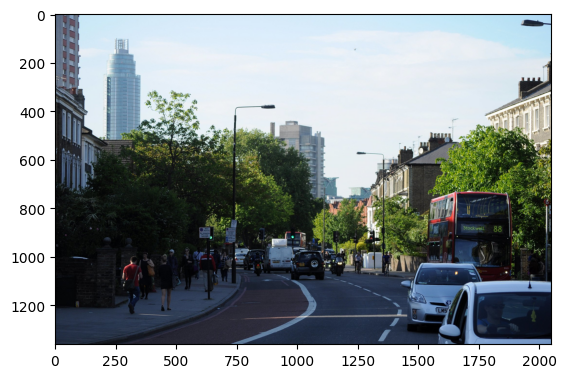

In [72]:
plt.imshow(cv2.cvtColor(rawInput, cv2.COLOR_BGR2RGB))

In [108]:
import torch
import mlx.core as mx

def convert_and_load(model, pt_path):
    sd = torch.load(pt_path, map_location='cpu')
    if 'model' in sd: sd = sd['model']
    
    mlx_params = {}
    for k, v in sd.items():
        val = v.numpy()
        if val.ndim == 4:
            # NHWC Transpose
            val = val.transpose(0, 2, 3, 1)
        
        parts = k.split('.')
        current = mlx_params
        for i in range(len(parts) - 1):
            p = parts[i]
            # If the current level is a list, and p is a digit, use list indexing
            if isinstance(current, list) and p.isdigit():
                idx = int(p)
                while len(current) <= idx: current.append({})
                current = current[idx]
            # If the model has a list (like 'projects'), build a list in the params
            elif p in ["projects", "blocks"]:
                if p not in current: current[p] = []
                current = current[p]
                # The next part MUST be a digit
                idx = int(parts[i+1])
                while len(current) <= idx: current.append({})
                # Skip the digit in the next loop iteration
                continue 
            else:
                if p not in current: current[p] = {}
                current = current[p]
        
        last = parts[-1]
        current[last] = mx.array(val)
    
    model.update(mlx_params)
    return model

In [109]:
depth_anything = DepthAnythingV2(encoder='vits')
depth_anything = convert_and_load(depth_anything, "/Users/adityadude/Documents/Python/AI/Depth-Anything-V2/checkpoints/depth_anything_v2_vits.pth")

ValueError: Module does not have parameter named "0".

In [107]:
depth_anything.infer_image(rawInput)

NameError: name 'interpolate_bilinear' is not defined

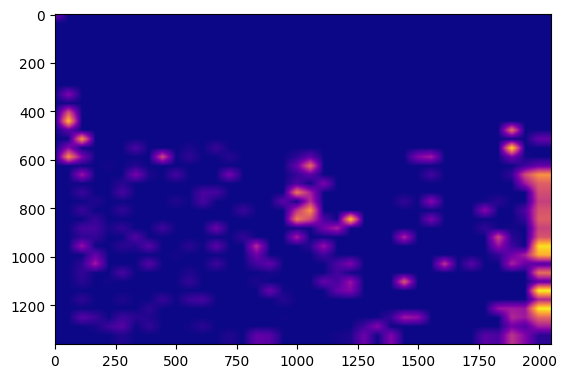

In [46]:
plt.imshow(depth_anything.infer_image(rawInput), cmap='plasma')

In [1]:
import cv2

In [2]:
cap =cv2.VideoCapture("/Users/adityadude/Documents/SadiGaliFarewellClip2.mp4")

In [6]:
captured_frames = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break


    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    captured_frames += 1

In [7]:
captured_frames 

796

In [8]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    cv2.imshow('Depth Anything V2 - Press Q to Quit', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break